# Image Classification

## Overview

Image classification assigns a label to an entire image. It is the foundation task of computer vision — architectures and techniques developed for classification underpin detection, segmentation, and retrieval.

**Architecture options:**

| Architecture | Params | Strengths | When to use |
|---|---|---|---|
| Small custom CNN | <1M | Fast, low memory | Very constrained resources |
| ResNet18/34 | 11–21M | Strong baseline | General purpose |
| EfficientNet-B0 | 5.3M | Accuracy/efficiency | Limited compute |
| ViT-small | 22M | Long-range patterns | Large datasets |

**ResNet key innovation:** skip connections (residual connections) allow gradients to flow directly through the network, enabling training of very deep architectures without vanishing gradients.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from copy import deepcopy

torch.manual_seed(42)
rng = np.random.default_rng(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from PIL import Image

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
N_CLASSES   = 3   # healthy / moderate / degraded
N_PER_CLASS = 500  # increased from 100 to reduce data scarcity
CLASS_NAMES = ['Healthy', 'Moderate', 'Degraded']

def make_patch(label, size=64, seed=0):
    r = np.random.default_rng(seed)

    # Tightened noise (±10 vs ±15–40) and anchored palette centres
    # so class distributions no longer overlap in RGB space
    palettes = {
        0: ([30,  50],  [140, 160], [40,  60]),   # healthy:  low-red, high-green, mid-blue
        1: ([90,  110], [100, 120], [50,  70]),   # moderate: mid-red, mid-green, mid-blue
        2: ([150, 170], [50,  70],  [20,  40]),   # degraded: high-red, low-green, low-blue
    }
    lo, hi = zip(*palettes[label])
    img = np.stack(
        [r.integers(lo[c], hi[c], (size, size)) for c in range(3)], axis=2
    ).astype(np.float32)

    # Label-specific stripe texture gives conv layers a learnable spatial signal
    stripe_gap = size // ((label + 1) * 2)
    if stripe_gap > 0:
        for row_start in range(0, size, stripe_gap * 2):
            img[row_start:min(row_start + 2, size), :, 1] = np.clip(
                img[row_start:min(row_start + 2, size), :, 1] + 40, 0, 255)

    return Image.fromarray(np.clip(img, 0, 255).astype(np.uint8))


all_imgs_raw   = [make_patch(lbl, seed=i + lbl * 600)
                  for lbl in range(N_CLASSES) for i in range(N_PER_CLASS)]
all_labels_raw = [lbl for lbl in range(N_CLASSES) for _ in range(N_PER_CLASS)]

# Shuffle before splitting so train/val/test each have balanced class counts
perm       = rng.permutation(len(all_imgs_raw))
all_imgs   = [all_imgs_raw[i]   for i in perm]
all_labels = [all_labels_raw[i] for i in perm]

split_tr, split_va = int(0.7 * len(all_imgs)), int(0.85 * len(all_imgs))
print(f"Train={split_tr}, Val={split_va-split_tr}, Test={len(all_imgs)-split_va}")


Train=1050, Val=225, Test=225


---
## Custom Dataset and ResNet-Style Architecture

In [2]:
class PatchDataset(Dataset):
    def __init__(self, imgs, labels, transform):
        self.imgs, self.labels, self.transform = imgs, labels, transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        return self.transform(self.imgs[i]), torch.tensor(self.labels[i], dtype=torch.long)

train_tfm = T.Compose([T.Resize((64,64)), T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(), T.ColorJitter(0.3,0.3,0.2),
    T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
eval_tfm  = T.Compose([T.Resize((64,64)), T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

train_dl = DataLoader(PatchDataset(all_imgs[:split_tr],         all_labels[:split_tr],         train_tfm), batch_size=32, shuffle=True)
val_dl   = DataLoader(PatchDataset(all_imgs[split_tr:split_va], all_labels[split_tr:split_va], eval_tfm),  batch_size=32)
test_dl  = DataLoader(PatchDataset(all_imgs[split_va:],         all_labels[split_va:],         eval_tfm),  batch_size=32)

# ResNet-style residual block
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels))
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.block(x) + x)   # skip connection

class MiniResNet(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.stem   = nn.Sequential(nn.Conv2d(3,32,3,padding=1,bias=False),
                                    nn.BatchNorm2d(32), nn.ReLU())
        self.layer1 = nn.Sequential(ResBlock(32), nn.MaxPool2d(2))
        self.layer2 = nn.Sequential(nn.Conv2d(32,64,1,bias=False),
                                    ResBlock(64), nn.MaxPool2d(2))
        self.head   = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                    nn.Dropout(0.4), nn.Linear(64, n_classes))
    def forward(self, x):
        return self.head(self.layer2(self.layer1(self.stem(x))))

model = MiniResNet(N_CLASSES).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Test forward: {model(torch.zeros(4,3,64,64).to(device)).shape}")


Parameters: 95,715
Test forward: torch.Size([4, 3])


---
## Training with Cosine Annealing

Best val acc: 1.000, Test acc: 1.000


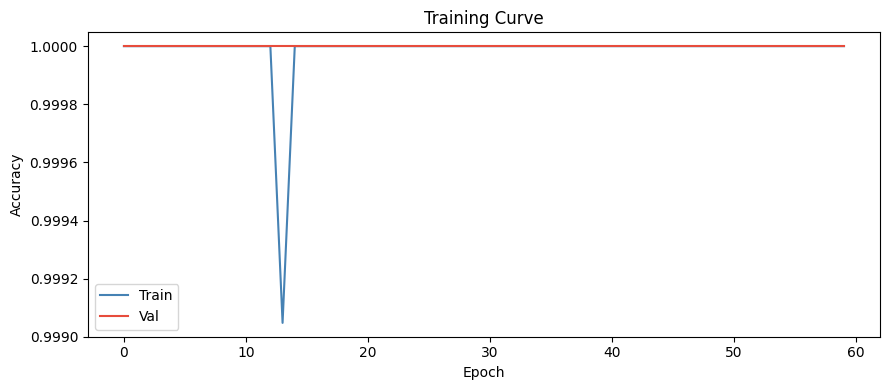

In [3]:
criterion = nn.CrossEntropyLoss()
optimiser = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=60)

def evaluate(model, dl):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in dl:
            out = model(Xb.to(device))
            correct += (out.argmax(1) == yb.to(device)).sum().item()
            total   += len(yb)
    return correct / total

best_acc, best_state = 0, None
tr_accs, va_accs = [], []
for epoch in range(60):
    model.train()
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        optimiser.zero_grad()
        criterion(model(Xb), yb).backward()
        optimiser.step()
    scheduler.step()
    tr_acc = evaluate(model, train_dl)
    va_acc = evaluate(model, val_dl)
    tr_accs.append(tr_acc); va_accs.append(va_acc)
    if va_acc > best_acc:
        best_acc = va_acc; best_state = deepcopy(model.state_dict())

model.load_state_dict(best_state)
test_acc = evaluate(model, test_dl)
print(f"Best val acc: {best_acc:.3f}, Test acc: {test_acc:.3f}")
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(tr_accs, label='Train', color='steelblue')
ax.plot(va_accs, label='Val',   color='#e74c3c')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title('Training Curve'); ax.legend()
plt.tight_layout(); plt.show()

---
## Confusion Matrix and Per-Class Analysis

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        79
    Moderate       1.00      1.00      1.00        72
    Degraded       1.00      1.00      1.00        74

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



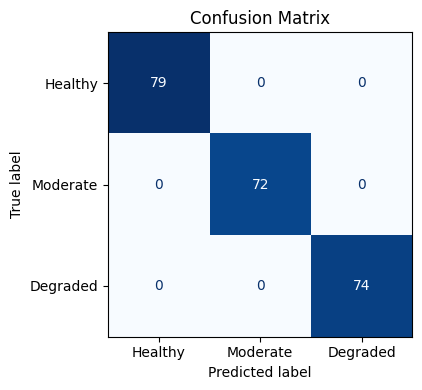

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for Xb, yb in test_dl:
        preds = model(Xb.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())
all_preds = np.array(all_preds)
all_true  = np.array(all_true)

print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(all_true, all_preds),
    display_labels=CLASS_NAMES
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix')
plt.tight_layout(); plt.show()


c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\torch\nn\modules\module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


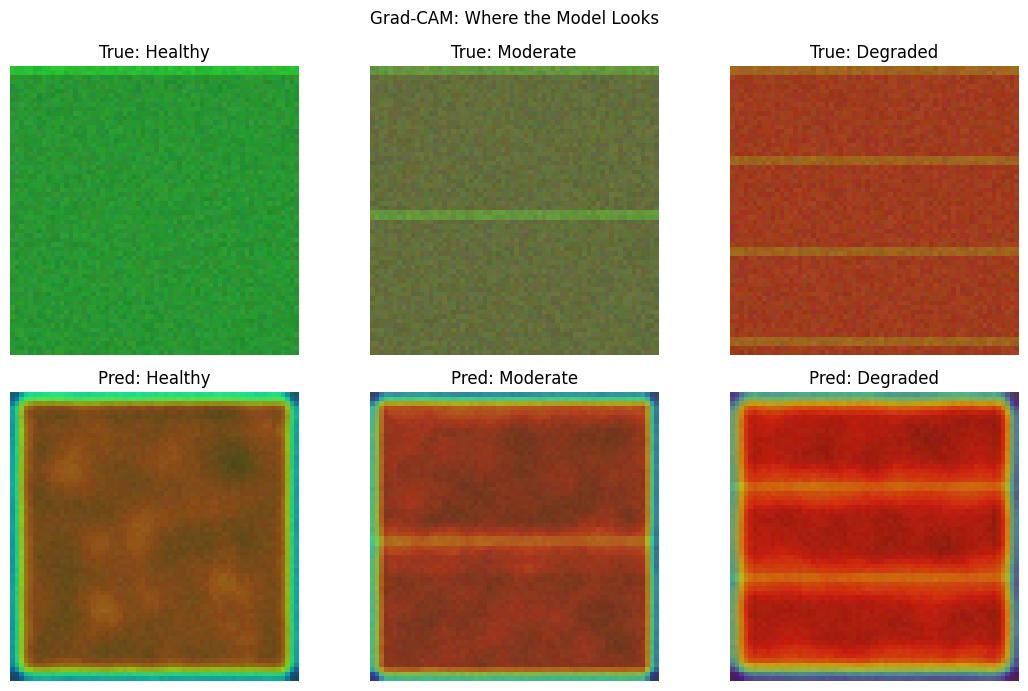

In [5]:
# Grad-CAM: visualise which image regions drove the prediction
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o))
        target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0]))
    def generate(self, x, class_idx):
        self.model.eval()
        out = self.model(x)
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(1).squeeze()
        cam = torch.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.detach().cpu().numpy()

gradcam = GradCAM(model, model.layer2[1].block[3])
# Pick one representative image per class from the original (pre-shuffle) list
sample_imgs = [all_imgs_raw[lbl * N_PER_CLASS] for lbl in range(N_CLASSES)]
fig, axes  = plt.subplots(2, N_CLASSES, figsize=(11, 7))
for col, (img, true_lbl) in enumerate(zip(sample_imgs, range(N_CLASSES))):
    tensor = eval_tfm(img).unsqueeze(0).to(device)
    pred   = model(tensor).argmax(1).item()
    cam    = gradcam.generate(tensor, pred)
    axes[0,col].imshow(img); axes[0,col].axis('off')
    axes[0,col].set_title(f'True: {CLASS_NAMES[true_lbl]}')
    axes[1,col].imshow(img)
    axes[1,col].imshow(np.array(Image.fromarray((cam*255).astype(np.uint8)).resize(img.size)),
                       cmap='jet', alpha=0.5)
    axes[1,col].axis('off')
    axes[1,col].set_title(f'Pred: {CLASS_NAMES[pred]}')
plt.suptitle('Grad-CAM: Where the Model Looks')
plt.tight_layout(); plt.show()


---

## Common Pitfalls

**1. Not using skip connections for networks deeper than ~6 layers**  
Without skip connections, gradients vanish through many sequential layers and training stalls. ResNet-style shortcuts allow gradients to flow directly from the loss to early layers. For any network deeper than ~6 conv layers, add residual connections.

**2. Using the test set to select the best checkpoint**  
If you evaluate on the test set after every epoch and keep the best epoch, you are implicitly using test-set information for model selection. The final reported accuracy is then optimistically biased. Always use a held-out validation set for checkpoint selection; evaluate on the test set exactly once at the end.

**3. Applying Grad-CAM to the wrong layer**  
Grad-CAM should be applied to the last convolutional layer before the global pooling — the layer with the richest spatial features. Applying it to early layers produces coarse, uninformative maps. Applying it after global pooling loses spatial information entirely.

**4. Interpreting class imbalance in accuracy without per-class breakdown**  
With 70% of images in one class, a classifier that always predicts that class achieves 70% accuracy. Always report per-class precision, recall, and F1 using `classification_report`, and inspect the confusion matrix to understand which classes are confused.

**5. Training without weight decay (L2 regularisation) on image models**  
Image CNNs have millions of parameters and overfit easily on small datasets. Always use `AdamW` (not `Adam`) with `weight_decay=1e-4` to 1e-2, or add explicit `nn.Dropout` layers. Monitor the train vs val accuracy gap — a widening gap signals overfitting that can be reduced with stronger regularisation or more augmentation.

---
*python_methods_library - Samantha McGarrigle*